# Product Classification with CNN
### A project by Francesco Cenerini, Enrico Strangio e Niccolò Leoncini
## Introduzione
Il progetto prende in esame la classificazione tramite CNN del dataset **Grocery Store** di immagini raffiguranti prodotti alimentari presenti in un supermercato.
Tale progetto è suddiviso in due parti distinte:
- **Task 1**: prevede la progettazione da zero di una rete neurale. In particolare, abbiamo sviluppato 5 diversi modelli di CNN, con l'obiettivo di superare le performance del modello precedente fino al raggiungimento di circa il 60% di validation accuracy;
- **Task 2**: prevede il fine-tuning di una ResNet-18 pre-addestrata su ImageNet sullo stesso dataset. In particolare, il fine-tuning viene effettuato utilizzando gli stessi iperparametri del miglior modello del Task 1 prima con il backbone congelato e poi scongelandolo per raggiungere tra l'80% e il 90% di validation accuracy.

In entrambi i task la valutazione finale viene effettuata sul *test set*, riservato esclusivamente alla misurazione delle prestazioni dei modelli migliori.

## Setup dell'ambiente
Come prima cosa, eseguiamo il download del dataset da GitHub ed installiamo i pacchetti necessari delle varie librerie che utilizzeremo all'interno del progetto.

In [ ]:
!git clone https://github.com/marcusklasson/GroceryStoreDataset.git
%pip install numpy matplotlib pandas tensorflow[and-cuda] keras-hub

fatal: destination path 'GroceryStoreDataset' already exists and is not an empty directory.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Conv2D,MaxPooling2D, BatchNormalization, Activation,Flatten, Dense, Dropout,GlobalAveragePooling2D, RandomFlip,RandomRotation,RandomZoom,RandomContrast, RandomTranslation, Concatenate
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import set_random_seed
from tensorflow.keras.backend import clear_session
from keras_hub import models
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import gc

os.environ["KERAS_BACKEND"] = "tensorflow"

I0000 00:00:1779711185.406936    1980 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779711186.058938    1980 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779711188.591360    1980 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Task 1
L'obiettivo di questo primo task è costruire una rete neurale interamente da zero partendo dai layer di base offerti da **Keras**, senza ricorrere ad architetture predefinite. L'approccio adottato è bottom-up: si parte dal modello più semplice possibile (**Model 1**) e si aggiunge complessità passo dopo passo, motivando ogni scelta con l'analisi dei grafici di training precedenti e verificando il miglioramento delle prestazioni.

## Configurazione
La fase di configurazione prevede di impostare le costanti che ci serviranno per l'intero sviluppo del Task 1, compresi gli iperparametri comuni per i vari modelli di CNN sviluppati. Ogni scelta è commentata con la sua motivazione.

In [ ]:
DATASET_DIR= 'GroceryStoreDataset/dataset/'

# Dimensione delle immagini: abbiamo scelto di utilizzare una dimensione delle immagini diversa
# da quella originale (192×192 invece che 384×384),
# in modo tale che la RAM non venga saturata durante l'addestramento e che
# non ci sia la perdita di troppi dettagli causati dalla dimensione troppo piccola delle immagini.
IMG_HEIGHT = 192
IMG_WIDTH = 192
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
CHANNELS = 3 # immagini RGB

BATCH_SIZE = 32 # equilibrio tra stabilità del gradiente e utilizzo della RAM GPU.
EPOCHS = 200 # max epochs 200: usiamo EarlyStopping per interrompere prima se necessario.
LEARNING_RATE = 0.001 # valore iniziale per Adam, verrà ridotto automaticamente con ReduceLROnPlateau

NUM_CLASSES  = 81   # classi fine-grained
NUM_SUPER    = 43   # classi coarse/gerarchiche usate solo per il Model 5

DROPOUT_RATE = 0.6 # valore alto per combattere l'overfitting su un dataset piccolo

# Impostazione del seed per la riproducibilita dei pesi negli esperimenti
SEED = 42

already_join = False
np.random.seed(SEED)
set_random_seed(SEED)

Definiamo anche due funzioni ausiliarie per la visualizzazione dei grafici riguardanti il training dei modelli.

In [ ]:
def plot(history):
  plt.figure(figsize=(20, 3))
  for i, metric in enumerate(["accuracy", "loss"]):
    plt.subplot(1, 2, i + 1)
    plt.plot(history.history[metric])
    plt.plot(history.history["val_" + metric])
    plt.title("Model {}".format(metric))
    plt.xlabel("epochs")
    plt.ylabel(metric)
    plt.legend(["train", "val"])

# Plotting grafici solo per il Model 5
def plot_multitask(history, model_name):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Fine class accuracy
    axes[0, 0].plot(history.history['f_accuracy'], label='Train')
    axes[0, 0].plot(history.history['val_f_accuracy'], label='Val')
    axes[0, 0].set_title("Fine Class (81) - Accuracy")
    axes[0, 0].set_ylabel("Accuracy")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Fine class loss
    axes[1, 0].plot(history.history['f_loss'], label='Train')
    axes[1, 0].plot(history.history['val_f_loss'], label='Val')
    axes[1, 0].set_title("Fine Class (81) - Loss")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Super class accuracy
    axes[0, 1].plot(history.history['s_accuracy'], label='Train')
    axes[0, 1].plot(history.history['val_s_accuracy'], label='Val')
    axes[0, 1].set_title("Super Class (43) - Accuracy")
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Super class loss
    axes[1, 1].plot(history.history['s_loss'], label='Train')
    axes[1, 1].plot(history.history['val_s_loss'], label='Val')
    axes[1, 1].set_title("Super Class (43) - Loss")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.suptitle(f"{model_name} - Multi-Task Training", fontsize=14)
    plt.tight_layout()
    plt.show()

Inoltre, è importante pulire l'ambiente di lavoro tra l'esecuzione di un modello e un altro per evitare che i grafi di Keras allocati in memoria vengano riutilizzati, causando output falsati. Dopo ogni test eseguiamo quindi la seguente funzione.

In [ ]:
def empty_cache():
    clear_session()
    gc.collect()

## Esplorazione del dataset
Il **Grocery Store Dataset** contiene 5125 immagini di prodotti alimentari scattate con la fotocamera degli smartphone in diversi supermercati. Le immagini sono suddivise in:
- **81 classi fine-grained** (es. *Granny Smith Apple*, *Banana*, *Oat Milk* …)
- **43 classi coarse** (macro-categorie, es. *Apple*, *Banana* …)

Il dataset è già suddiviso in `train, val e test` tramite file `.txt`.

Ora, carichiamo i file `.csv` che contengono le label delle immagini e sono strutturati nel modo seguente: *Image Path, Class, Coarse Class*.

In [ ]:
train_path = os.path.join(DATASET_DIR, 'train.txt')
val_path = os.path.join(DATASET_DIR,'val.txt')
test_path = os.path.join(DATASET_DIR,'test.txt')
classes_path = os.path.join(DATASET_DIR, 'classes.csv')

names = ["Image path", "Class", "Coarse class"]
df_train = pd.read_csv(train_path, names=names)
df_val = pd.read_csv(val_path, names=names)
df_test = pd.read_csv(test_path, names=names)
df_classes = pd.read_csv(classes_path)

df_train.head()

,Image path,Class,Coarse class
0,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
1,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
2,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
3,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
4,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0


Come possiamo vedere sopra, ogni immagine ha due label: la prima specifica la classe più generica, l'altra una classe più specifica. Terremo a mente questa particolare struttura perché la sfrutteremo successivamente nell'ultimo modello.

Mostriamo, adesso, le label fine-grained e coarse del dataset.

In [ ]:

unique_classes=df_classes.iloc[:, 0].unique()
unique_coarse_classes=df_classes.iloc[:, 2].unique()

print(f"Number of coarse classes: {len(unique_coarse_classes)}")
print(f"{unique_coarse_classes}\n\n")

print(f"Number of specific classes: {len(unique_classes)}")
print(f"{unique_classes}")

Number of coarse classes: 43
<StringArray>
[         'Apple',        'Avocado',         'Banana',           'Kiwi',
          'Lemon',           'Lime',          'Mango',          'Melon',
      'Nectarine',         'Orange',         'Papaya',  'Passion-Fruit',
          'Peach',           'Pear',      'Pineapple',           'Plum',
    'Pomegranate', 'Red-Grapefruit',       'Satsumas',          'Juice',
           'Milk',       'Oatghurt',       'Oat-Milk',     'Sour-Cream',
      'Sour-Milk',       'Soyghurt',       'Soy-Milk',        'Yoghurt',
      'Asparagus',      'Aubergine',        'Cabbage',        'Carrots',
       'Cucumber',         'Garlic',         'Ginger',           'Leek',
       'Mushroom',          'Onion',         'Pepper',         'Potato',
       'Red-Beet',         'Tomato',       'Zucchini']
Length: 43, dtype: str


Number of specific classes: 81
<StringArray>
[                      'Golden-Delicious',
                           'Granny-Smith',
                

## Creazione dei dataset
Abbiamo creato una funzione ausiliaria che caricherà le immagini dal percorso del csv, le decodificherà, eseguirà il resize alla dimensione che abbiamo specificato sopra e normalizzerà i valori da interi nel range $[0,255]$ a floating point in $[0, 1]$, poiché le reti neurali lavorano meglio con numeri in virgola mobile.

In [ ]:
def load_image(image_path, label):
    file = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(file, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255
    return image, label

Creiamo, inoltre, una seconda funzione che ci permetterà di convertire i dataframe della libreria **Pandas** in tensori, attraverso i quali costruiremo i dataset su cui lavoreranno i nostri modelli.

In [ ]:
def get_dataset(df, train, super_label=False):
    # Inserimento percorso assoluto delle immagini
    if not already_join:
        df[names[0]] = df[names[0]].apply(
            lambda i: str(os.path.join(DATASET_DIR, i.strip()))
        )

    image = df[names[0]].values
    # Creazione tensore delle immagini
    x = tf.convert_to_tensor(image, dtype=tf.string)
    # Creazione tensore delle label specifiche
    y = tf.convert_to_tensor(df[names[1]].astype(int).values, dtype=tf.int32)
    if super_label:
        # Creazione tensore delle label grezze per il Model 5 (fine e coarse label)
        y_coarse = tf.convert_to_tensor(df[names[2]].astype(int).values, dtype=tf.int32)
        y = (y_coarse, y)

    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    # Caricamento immagini
    dataset = dataset.map(load_image)
    if train: dataset = dataset.shuffle(len(df))
    dataset = dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

In [ ]:
train_dataset = get_dataset(df_train, True)
val_dataset = get_dataset(df_val, False)
test_dataset = get_dataset(df_test, False)
already_join=True

Abbiamo così ottenuto tre dataset distinti su cui svolgeremo il training, la validation e il test.

## Input layer e callbacks
Definiamo una funzione che ci permetterà di creare l'input layer, che servirà a definire che tipo di dati dare in ingresso alla rete neurale. Nei modelli faremo uso della data augmentation, che ci aiuterà a mitigare, in parte, i problemi di apprendimento che le reti neurali hanno con dataset troppo piccoli. Le trasformazioni scelte simulano le variabilità realistiche delle fotografie:
- `RandomFlip('horizontal')`: un prodotto può essere fotografato da sinistra o da destra.
- `RandomRotation(0.2)`: leggere inclinazioni (±36°) sono comuni in foto scattate a mano.
- `RandomZoom(0.2)`: distanze diverse dalla fotocamera producono scale diverse.
- `RandomContrast(0.2)`: l'illuminazione dei supermercati non è sempre uniforme.
- `RandomTranslation(0.1, 0.1)`: il soggetto non è sempre centrato.

In [ ]:
def input_layer(data_augmentation = True):

    # Costruisce il blocco di input per ogni modello.
    inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS))
    x = inputs   # variabile separata per costruire il grafo

    if data_augmentation:
        x = RandomFlip("horizontal")(x)
        x = RandomRotation(0.2)(x)
        x = RandomZoom(0.2)(x)
        x = RandomContrast(0.2)(x)
        x = RandomTranslation(0.1, 0.1)(x)

    return inputs, x

Per velocizzare ed aiutare il modello a convergere usiamo la callback `ReduceLROnPlateau`: se la *validation loss* non migliora dopo $x$ epoche, vuol dire che stiamo rimbalzando da un fronte all'altro della funzione di loss, quindi il *learning rate* viene dimezzato in modo automatico, per riprendere la discesa verso il minimo locale.

Allo stesso modo se il modello ha smesso di imparare dopo $y$ epoche vuol dire che il modello ha già raggiunto il minimo locale e ulteriori epoche sono completamente inutili, sfruttiamo così la callback `EarlyStopping` per fermare l'addestramento in anticipo.

L'utilizzo delle callbacks aumenta, tuttavia, il numero di iperparametri da impostare.

In [ ]:
def fit_model(model, monitor_early_stopping="val_accuracy", patience_early_stopping=40, monitor_reduce_lr="val_loss", patience_reduce_lr=8):

    # Restituisce le callback standard usate in tutti gli esperimenti dei modelli

    fit = model.fit(train_dataset, validation_data=val_dataset,epochs=EPOCHS, callbacks=[
      EarlyStopping(
          monitor=monitor_early_stopping,
          patience=patience_early_stopping,
          mode="max",
          restore_best_weights=True, # ripristiniamo i pesi migliori
          verbose=1
      ),
      ReduceLROnPlateau(
          monitor=monitor_reduce_lr,
          factor=0.5,
          patience=patience_reduce_lr,
          mode="min",
          verbose=1,
          min_lr=1e-5
      ),
    ])
    return fit

## Modello 1
Il primo modello presenta 3 blocchi convoluzionali con filtri (32 -> 64 -> 128) seguiti da un layer Fully Connected (`Flatten+Dense`) e un output softmax a 81 neuroni. L'ottimizzatore è Adam con impostazioni di default.
Questo modello viene addestrato volutamente senza nessuna data augmentation e nessuna batch normalization: vogliamo vedere le prestazioni del dataset di base senza aiuti per avere una baseline su cui misurare i miglioramenti successivi.

In [ ]:
def model1():
  inputs, x = input_layer(False) # no data augmentation

  # Blocco 1: estrae feature di basso livello (bordi, texture)
  x = Conv2D(filters=32, kernel_size=3, padding="same", activation="relu")(x)
  x = MaxPooling2D()(x)

  # Blocco 2: feature di livello medio (forme, pattern)
  x = Conv2D(filters=64, kernel_size=3, padding="same", activation="relu")(x)
  x = MaxPooling2D()(x)

  # Blocco 3: feature di alto livello (parti di oggetti)
  x = Conv2D(filters=128, kernel_size=3, padding="same", activation="relu")(x)
  x = MaxPooling2D()(x)

  # Flatten: appiattisce le feature map in un vettore 1D
  x = Flatten()(x)

  # Dense FC: combina le feature spaziali in una rappresentazione globale
  x = Dense(units=256, activation="relu")(x)

  # Output: 81 neuroni (una per classe), softmax per probabilità
  outputs = Dense(units=NUM_CLASSES, activation="softmax")(x)

  model = Model(name="model1", inputs=inputs, outputs=outputs)
  model.compile(
      optimizer=Adam(learning_rate=LEARNING_RATE),
      loss='sparse_categorical_crossentropy',
      metrics=["accuracy"],
      jit_compile="auto" # Usa la compilazione JIT (XLA) quando possibile per ottimizzare le prestazioni
    )
  return model

In [ ]:
# Costruzione e summary del modello
model1 = model1()
model1.summary()

W0000 00:00:1779661434.966895    6381 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779661434.967856    6377 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779661434.969417    6386 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779661434.970113    6382 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779661434.971579    6385 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779661434.972666    6376 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779661434.974383    6383 gpu_kernel_to_blob_pass.cc:190] Failed to co

Model: "model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 192, 192, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    18,874,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 81)             │        20,817 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,988,689 (72.44 MB)

 Trainable params: 18,988,689 (72.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200


W0000 00:00:1779661436.699243    6436 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779661436.700922    6433 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779661436.701494    6438 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779661436.722668    6436 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779661436.725754    6433 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779661436.740484    6436 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779661436.742535    6433 gpu_kernel_to_blob_pass.cc:190] Failed to co

83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.1212 - loss: 3.6088 - val_accuracy: 0.1115 - val_loss: 3.2942 - learning_rate: 0.0010
Epoch 2/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.4947 - loss: 1.8147 - val_accuracy: 0.1723 - val_loss: 3.4768 - learning_rate: 0.0010
Epoch 3/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7072 - loss: 0.9730 - val_accuracy: 0.2162 - val_loss: 3.9617 - learning_rate: 0.0010
Epoch 4/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8398 - loss: 0.5152 - val_accuracy: 0.1554 - val_loss: 5.2566 - learning_rate: 0.0010
Epoch 5/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8841 - loss: 0.3617 - val_accuracy: 0.1858 - val_loss: 5.0230 - learning_rate: 0.0010
Epoch 6/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9277 - loss: 0.2535 - val_accuracy: 0.2365 - val_loss: 5.6855 - learning_rate: 0.0010
Epoch 7/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9716 - loss: 0.1016 - val_accuracy

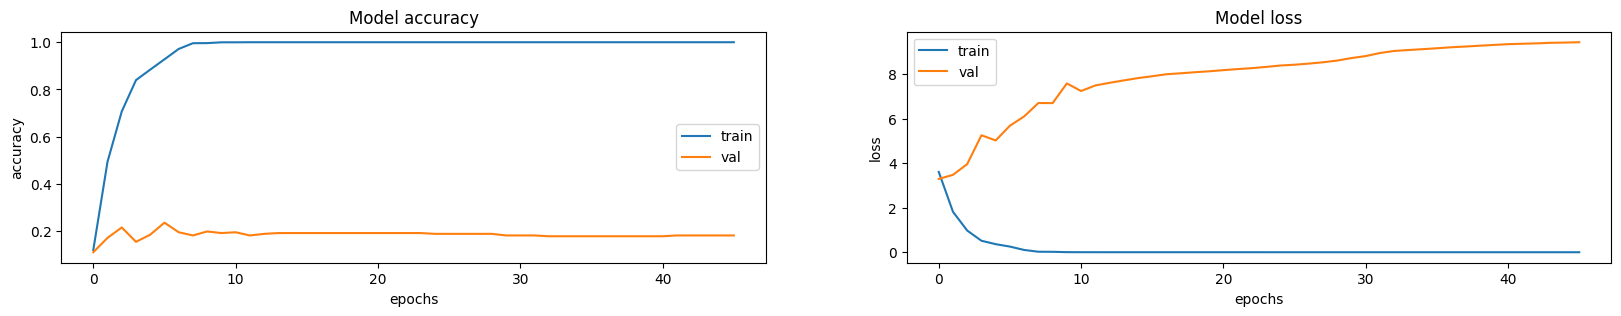

In [ ]:
# Training Model 1
result = fit_model(model1)
plot(result)

# Valutazione Model 1
test = model1.evaluate(test_dataset)
test_loss, test_acc = test[0], test[1]

print(f"Test Accuracy: {test_acc * 100:.2f}%\nTest Loss: {test_loss}")

In [ ]:
del model1
empty_cache()

### Risultati del modello 1
Dalle metriche del modello e dal grafico di training possiamo vedere subito come il primo modello vada in overfitting rispetto al set di validazione. Ciò è probabilmente dovuto dalla carenza di esempi (appena 45 per classe), più che dalla complessità del modello stesso. Dovremmo quindi introdurre la data augmentation per incrementare il numero di esempi del dataset.

## Modello 2
Dato l'overfitting pronunciato e il training instabile del **Model 1**, introduciamo nel secondo modello le seguenti modifiche:
1. **Batch Normalization**: normalizza le attivazioni ad ogni mini-batch, riducendo il covariate shift interno. Va applicata prima dell'attivazione nei layer Conv2D e Dense (ad es. Conv -> BN -> ReLU)

2. **Data Augmentation**: aumenta artificialmente la diversità del training set applicando trasformazioni casuali alle immagini, costringendo il modello a imparare feature invarianti alle trasformazioni in modo da aumentare la generalizzazione.

3. **Dropout(0.6)** nel classificatore: disattiva casualmente il 60% dei neuroni durante il training, forzando ridondanza nelle rappresentazioni.

4. **Introduzione di un nuovo blocco Conv (filtri 16 -> 32 -> 64 -> 128)**: più capacità espressiva grazie alla normalizzazione che ne consente un training più stabile.

In [ ]:
def model2():
    inputs, x = input_layer() # data augmentation attiva

    # Blocco 1 — filtri ridotti (16 invece di 32) per compensare i 4 blocchi
    x = Conv2D(filters=16, kernel_size=3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    # Blocco 2
    x = Conv2D(filters=32, kernel_size=3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    # Blocco 3
    x = Conv2D(filters=64, kernel_size=3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    # Blocco 4
    x = Conv2D(filters=128, kernel_size=3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    x = Flatten()(x)

    # Abbiamo diminuito il numero di unità (neuroni) da 256 a 128 del Dense e aggiunto un ulteriore layer
    x = Dense(units=128, use_bias=False)(x) # use_bias=False perché la BN ha già il proprio bias
    x = Activation('relu')(x)
    x = BatchNormalization()(x)
    x = Dense(units=128, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(DROPOUT_RATE)(x)

    outputs = Dense(units=81, activation="softmax")(x)

    model = Model(name="model2", inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
        jit_compile="auto"
    )
    return model

In [ ]:
model2=model2()
model2.summary()

Model: "model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 192, 192, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 192, 192, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 192, 192, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 192, 192, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 192, 192, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 192, 192, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 96, 96, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,485,553 (9.48 MB)

 Trainable params: 2,484,561 (9.48 MB)

 Non-trainable params: 992 (3.88 KB)

Epoch 1/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.0549 - loss: 4.2952 - val_accuracy: 0.0203 - val_loss: 4.9452 - learning_rate: 0.0010
Epoch 2/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.1080 - loss: 3.5926 - val_accuracy: 0.0304 - val_loss: 4.9650 - learning_rate: 0.0010
Epoch 3/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.1557 - loss: 3.2053 - val_accuracy: 0.0372 - val_loss: 4.6833 - learning_rate: 0.0010
Epoch 4/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.1905 - loss: 2.9137 - val_accuracy: 0.1014 - val_loss: 3.4824 - learning_rate: 0.0010
Epoch 5/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.2364 - loss: 2.7177 - val_accuracy: 0.0878 - val_loss: 3.2194 - learning_rate: 0.0010
Epoch 6/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.2894 - loss: 2.4705 - val_accuracy: 0.1959 - val_loss: 2.9557 - learning_rate: 0.0010
Epoch 7/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.3348 - loss: 2.2776 - 

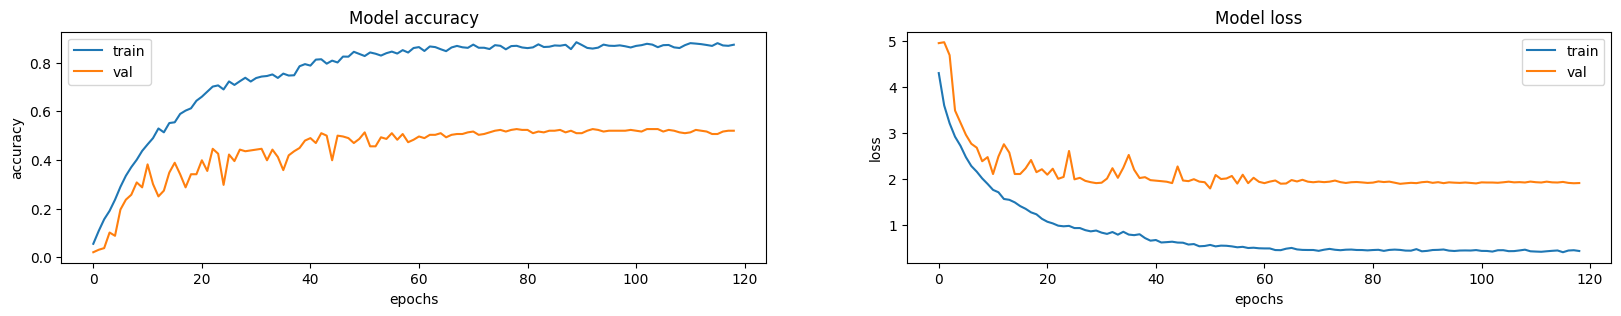

In [ ]:
result = fit_model(model2)
plot(result)

test = model2.evaluate(test_dataset)
test_loss,test_acc=test[0],test[1]

print(f"Test Accuracy: {test_acc * 100:.2f}%\nTest Loss: {test_loss}")

In [ ]:
del model2
empty_cache()

### Risultati del modello 2

Rispetto al **Model 1**, il gap tra training e validation accuracy si riduce nettamente, segno che l'overfitting è stato parzialmente contenuto. Le curve di training risultano significativamente più regolari grazie alla batch normalization, che stabilizza la distribuzione delle attivazioni a ogni mini-batch. La validation accuracy registra un incremento di circa **34 punti percentuali** (da 18.24% a 52.03%), mentre la test loss si riduce di circa **3 volte** (da 4.19 a 1.31), riflettendo una maggiore capacità del modello di generalizzare su dati non visti. La test accuracy raggiunge **58.99%**, avvicinandosi all'obiettivo del 60% fissato.

Permane, tuttavia, un gap non trascurabile tra training accuracy (circa 87%) e validation accuracy (circa 52%), indicativo di un overfitting residuo imputabile principalmente alla limitata dimensione del training set.

## Modello 3
Il secondo modello usava `Flatten` dopo gli strati convoluzionali. Con feature map $12 \times 12 \times 128$, il Flatten produce $18.432$ elementi quindi inserendo successivamente un Dense si introduce una matrice di pesi con milioni di parametri. Questo provoca un potenziale overfitting su un dataset piccolo come il nostro.

Perciò, abbiamo pensato di inserire il **Global Average Pooling (GAP)** per risolvere questo problema: invece di appiattire ogni elemento, calcola la media spaziale di ciascun canale, producendo un vettore di dimensione uguale al numero di canali (256 nel quarto blocco). Il Dense successivo avrà $256 \times 128 = 32.768$ parametri, circa due ordini di grandezza in meno. Oltre alla riduzione dei parametri, il GAP ha un effetto regolarizzante intrinseco: aggregando l'informazione con una media, forza il backbone a distribuire le feature discriminative su tutta la feature map anziché in pattern localizzati. Questo rende il modello più robusto alla posizione del soggetto.

Infine, abbiamo aumentato la dimensione dei filtri convoluzionali partendo da 32 fino a 256 nell'ultimo blocco ed abbiamo ridotto il Dense ad uno da 128.

In [ ]:
def model3():
    inputs, x = input_layer()

    x = Conv2D(filters=32, kernel_size=3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    x = Conv2D(filters=64, kernel_size=3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    x = Conv2D(filters=128, kernel_size=3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    x = Conv2D(filters=256, kernel_size=3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    x = GlobalAveragePooling2D()(x)

    x = Dense(units=128, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(DROPOUT_RATE)(x)

    outputs = Dense(units=81, activation="softmax")(x)

    model = Model(name="model3", inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
        jit_compile="auto"
    )
    return model


In [ ]:
model3=model3()
model3.summary()

Model: "model3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 192, 192, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 192, 192, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 192, 192, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 192, 192, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 192, 192, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 192, 192, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 96, 96, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 434,065 (1.66 MB)

 Trainable params: 432,849 (1.65 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.0871 - loss: 4.0185 - val_accuracy: 0.0304 - val_loss: 4.6192 - learning_rate: 0.0010
Epoch 2/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.1587 - loss: 3.2495 - val_accuracy: 0.0203 - val_loss: 4.9393 - learning_rate: 0.0010
Epoch 3/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.2004 - loss: 2.9248 - val_accuracy: 0.0169 - val_loss: 5.9567 - learning_rate: 0.0010
Epoch 4/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.2568 - loss: 2.6704 - val_accuracy: 0.0304 - val_loss: 4.7902 - learning_rate: 0.0010
Epoch 5/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - accuracy: 0.2860 - loss: 2.5163 - val_accuracy: 0.0709 - val_loss: 4.0966 - learning_rate: 0.0010
Epoch 6/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.3205 - loss: 2.3601 - val_accuracy: 0.2297 - val_loss: 2.8310 - learning_rate: 0.0010
Epoch 7/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.3697 - loss: 2.1614

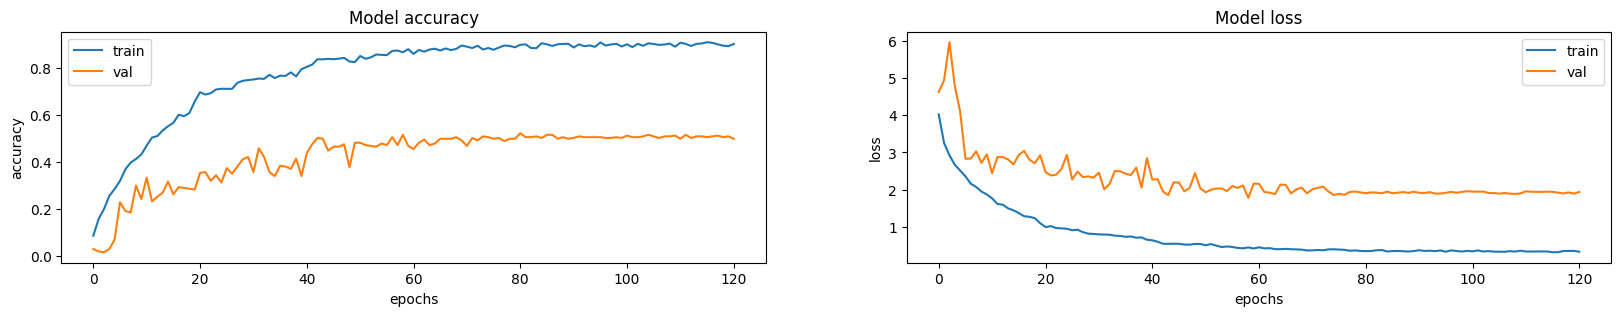

In [ ]:
result = fit_model(model3)
plot(result)

test=model3.evaluate(test_dataset)
test_loss,test_acc=test[0],test[1]

print(f"Test Accuracy: {test_acc * 100:.2f}%\nTest Loss: {test_loss}")

In [ ]:
del model3
empty_cache()

### Risultati del modello 3

L'introduzione del `GlobalAveragePooling2D` ha ridotto drasticamente il numero di parametri addestrabili (da circa 2.5M a 434K), eliminando la matrice di pesi densa prodotta dal Flatten. Le curve di addestramento risultano più regolari rispetto al **Model 2**, con una convergenza più stabile e priva dei bruschi movimenti a "zig-zag" che caratterizzavano il modello precedente.

Tuttavia, la test accuracy subisce una lieve regressione rispetto al modello precedente: **55.13% vs 58.99%**. La riduzione di capacità rappresentativa introdotta dal GAP, pur benefica in termini di regolarizzazione implicita, risulta eccessiva per il numero di classi da discriminare (81). Il **Model 3** costituisce pertanto un passo intermedio importante che motiva le scelte del **Model 4**: la convergenza più stabile e la riduzione dei parametri rappresentano la base su cui aggiungere profondità e capacità estrattiva senza rischiare un ritorno all'overfitting severo del primo modello ed evitare tempi molto lunghi nell'addestramento.

## Modello 4
Nel quarto modello abbiamo deciso di incrementare lo spazio delle feature e di ridurre le dimensioni dell'output dei layer convoluzionali da $12 \times 12 \times 256$ a $4 \times 4 \times 512$. In questo modo si punta a ridurre la **dipendenza spaziale** tra i pixel e ad aumentare il numero di feature da apprendere. A tal fine, è stato aggiunto un ulteriore blocco convoluzionale da 512 filtri e rimosso il padding da tutti i layer convoluzionali già presenti nel modello precedente.

Come ulteriore intervento di regolarizzazione, è stata adottata la tecnica del "weight decay": viene introdotta la penalità L2 sui pesi, aggiungendo un termine **regolarizzatore** alla funzione di loss. Questa tecnica penalizza i pesi di grande magnitudine, spingendo il modello a distribuire l'informazione su più feature e riducendo la dipendenza da singoli neuroni.

In [ ]:
def model4():
    wd = 1e-4 # valore standard di weight decay
    inputs, x = input_layer()

    x = Conv2D(filters=32, kernel_size=3, kernel_regularizer=l2(wd))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    x = Conv2D(filters=64, kernel_size=3, kernel_regularizer=l2(wd))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    x = Conv2D(filters=128, kernel_size=3, kernel_regularizer=l2(wd))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    x = Conv2D(filters=256, kernel_size=3, kernel_regularizer=l2(wd))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    x = Conv2D(filters=512, kernel_size=3, kernel_regularizer=l2(wd))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    x = GlobalAveragePooling2D()(x)

    x = Dense(units=128, use_bias=False, kernel_regularizer=l2(wd))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(DROPOUT_RATE)(x)

    outputs = Dense(units=81, activation="softmax")(x)

    model = Model(name="model4", inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
        jit_compile="auto"
    )
    return model


In [ ]:
model4=model4()
model4.summary()

Model: "model4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 192, 192, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 192, 192, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 192, 192, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 190, 190, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 190, 190, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 190, 190, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 95, 95, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 93, 93, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 93, 93, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 93, 93, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 44, 44, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 44, 44, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 44, 44, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,649,041 (6.29 MB)

 Trainable params: 1,646,801 (6.28 MB)

 Non-trainable params: 2,240 (8.75 KB)

Epoch 1/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.0837 - loss: 4.0400 - val_accuracy: 0.0169 - val_loss: 5.0091 - learning_rate: 0.0010
Epoch 2/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.1689 - loss: 3.2617 - val_accuracy: 0.0203 - val_loss: 5.5887 - learning_rate: 0.0010
Epoch 3/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.2341 - loss: 2.8969 - val_accuracy: 0.0203 - val_loss: 5.5047 - learning_rate: 0.0010
Epoch 4/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.2795 - loss: 2.5967 - val_accuracy: 0.0169 - val_loss: 6.1231 - learning_rate: 0.0010
Epoch 5/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.3227 - loss: 2.4308 - val_accuracy: 0.1149 - val_loss: 3.6937 - learning_rate: 0.0010
Epoch 6/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.3826 - loss: 2.2237 - val_accuracy: 0.2399 - val_loss: 2.7337 - learning_rate: 0.0010
Epoch 7/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.4106 - loss: 2.0955 

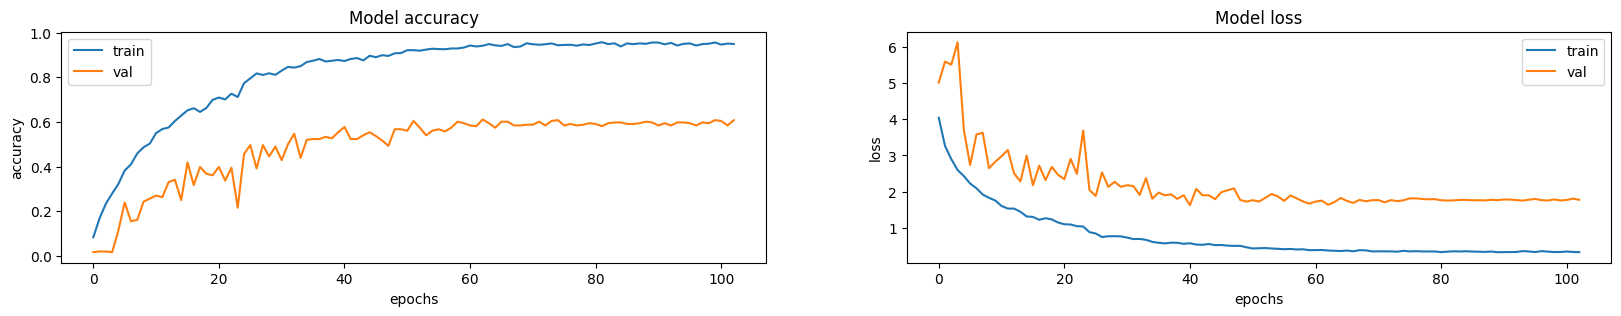

In [ ]:
result = fit_model(model4)
plot(result)

test=model4.evaluate(test_dataset)
test_loss,test_acc=test[0],test[1]

print(f"Test Accuracy: {test_acc * 100:.2f}%\nTest Loss: {test_loss}")

In [ ]:
del model4
empty_cache()

### Risultati del modello 4

L'aggiunta del quinto blocco convoluzionale (512 filtri) e la rimozione del padding hanno prodotto un incremento di circa **11 punti percentuali** sulla test accuracy rispetto al **Model 3** (66.16% vs 55.13%), con la validation accuracy che raggiunge **60.81%**, superando il target del 60%. La test loss rimane in linea con il **Model 2** ma con una capacità estrattiva significativamente maggiore.

Nonostante l'impiego di **batch normalization**, **kernel regularizer L2** e **data augmentation**, il modello manifesta ancora un gap tra training accuracy (circa 95%) e validation accuracy (circa 61%), sintomo di overfitting residuo dovuto alla limitata dimensione del dataset. Questo risultato conferma che, in presenza di dataset ridotti, le tecniche di regolarizzazione tradizionali non sono sufficienti a colmare il divario, motivando l'approccio multi-task esplorato nel **Model 5**.

## Modello 5
L'obiettivo di questo ultimo modello è stato quello di sfruttare la presenza delle label più generiche per guidare il modello nella predizione e per ridurre la possibilità di errori tra classi generiche diverse. Mantenendo quindi la stessa struttura di filtri convoluzionali del **Model 4** abbiamo concatenato due classificatori diversi uno con 43 neuroni, per la classificazione delle label generiche, concatenato a uno da 81, per classificare le label specifiche. Avendo due etichette da predire, dobbiamo anche scegliere come pesarle, perciò impostiamo il peso delle label generiche a 0.8 e quella delle label specifiche a 1. Questo perchè il nostro obiettivo rimane la classificazione corretta delle label specifiche: quelle generiche devono servire solamente come linee guida per il nostro modello.

In [ ]:
def model5():
    wd = 1e-3 # abbiamo abbassato il valore di weight decay per ridurre l'effetto regolarizzante
    inputs, x = input_layer()

    conv = Conv2D(filters=32, kernel_size=3, kernel_regularizer=l2(wd))(x)
    conv = BatchNormalization()(conv)
    conv = Activation('relu')(conv)
    conv = MaxPooling2D()(conv)

    conv = Conv2D(filters=64, kernel_size=3, kernel_regularizer=l2(wd))(conv)
    conv = BatchNormalization()(conv)
    conv = Activation('relu')(conv)
    conv = MaxPooling2D()(conv)

    conv = Conv2D(filters=128, kernel_size=3, kernel_regularizer=l2(wd))(conv)
    conv = BatchNormalization()(conv)
    conv = Activation('relu')(conv)
    conv = MaxPooling2D()(conv)

    conv = Conv2D(filters=256, kernel_size=3, kernel_regularizer=l2(wd))(conv)
    conv = BatchNormalization()(conv)
    conv = Activation('relu')(conv)
    conv = MaxPooling2D()(conv)

    conv = Conv2D(filters=512, kernel_size=3, kernel_regularizer=l2(wd))(conv)
    conv = BatchNormalization()(conv)
    conv = Activation('relu')(conv)
    conv = MaxPooling2D()(conv)

    conv = GlobalAveragePooling2D()(conv)

    dense = Dense(units=128, use_bias=False, kernel_regularizer=l2(wd))(conv)
    dense = BatchNormalization()(dense)
    dense = Activation('relu')(dense)
    dense = Dropout(DROPOUT_RATE)(dense)

    super_class = Dense(units=43, activation='softmax', name="s")(dense)
    combined = Concatenate()([dense, super_class])
    # combined ha 171 valori (feature estratte da cnn + numero di classi coarse grained),
    # questo è ciò che viene passato a fine_class

    fine_class = Dense(units=81, activation='softmax', name="f")(combined)
    model = Model(name = "model5", inputs=inputs, outputs=[super_class, fine_class])
    model.compile(
        optimizer=Adam(LEARNING_RATE),
        jit_compile=False, # Disabilita XLA per evitare problemi di compatibilità con il modello multi-output
        loss={
            's': 'sparse_categorical_crossentropy',
            'f': 'sparse_categorical_crossentropy'
        },
        loss_weights={
            's': 0.8,
            'f': 1.0
        },
        metrics={
            's': 'accuracy',
            'f': 'accuracy',
        }
    )
    return model

In [ ]:
model5=model5()
model5.summary()

Model: "model5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 192, 192,  │          0 │ input_layer[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 192, 192,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 192, 192,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast     │ (None, 192, 192,  │          0 │ random_zoom[0][0] │
│ (RandomContrast)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation  │ (None, 192, 192,  │          0 │ random_contrast[… │
│ (RandomTranslation) │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 190, 190,  │        896 │ random_translati… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 190, 190,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 190, 190,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 95, 95,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 93, 93,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 93,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 93, 93,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 46, 46,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 44, 44,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 44,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 44, 44,    │          0 │ batch_normalizat

 Total params: 1,658,071 (6.33 MB)

 Trainable params: 1,655,831 (6.32 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [ ]:
train_dataset = get_dataset(df_train, True, super_label=True)
val_dataset = get_dataset(df_val, False, super_label=True)
test_dataset = get_dataset(df_test, False,super_label=True)

Epoch 1/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 108ms/step - f_accuracy: 0.0780 - f_loss: 4.0568 - loss: 7.5213 - s_accuracy: 0.1875 - s_loss: 3.2162 - val_f_accuracy: 0.0203 - val_f_loss: 4.7277 - val_loss: 8.5680 - val_s_accuracy: 0.0676 - val_s_loss: 3.9207 - learning_rate: 0.0010
Epoch 2/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - f_accuracy: 0.1568 - f_loss: 3.2513 - loss: 6.0880 - s_accuracy: 0.3076 - s_loss: 2.4884 - val_f_accuracy: 0.0304 - val_f_loss: 4.8181 - val_loss: 8.5402 - val_s_accuracy: 0.1115 - val_s_loss: 3.9816 - learning_rate: 0.0010
Epoch 3/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - f_accuracy: 0.2038 - f_loss: 2.8967 - loss: 5.4551 - s_accuracy: 0.3595 - s_loss: 2.2023 - val_f_accuracy: 0.0236 - val_f_loss: 5.0414 - val_loss: 9.0603 - val_s_accuracy: 0.0845 - val_s_loss: 4.3243 - learning_rate: 0.0010
Epoch 4/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - f_accuracy: 0.2462 - f_loss: 2.6466 - loss: 4.9657 - s_accuracy: 0.4231 - s_loss: 1.9562 - val_f_accuracy: 0.1

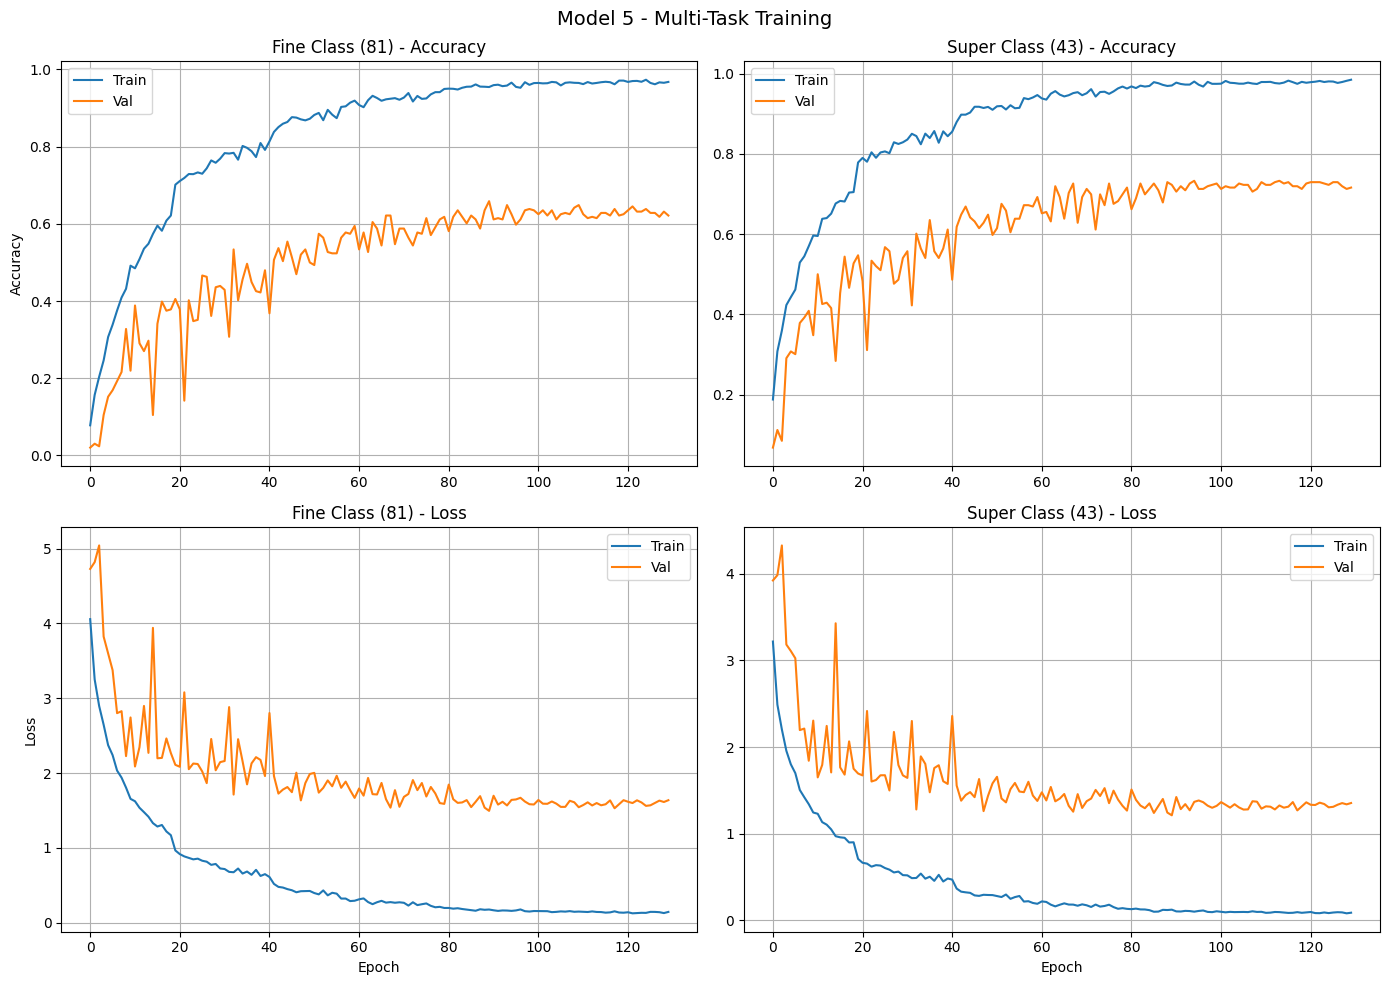

78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - f_accuracy: 0.7010 - f_loss: 1.0330 - loss: 2.0994 - s_accuracy: 0.7730 - s_loss: 0.8811
Test: [2.0993919372558594, 0.8811107277870178, 1.0330018997192383, 0.7010060548782349, 0.7730382084846497]


In [ ]:
result = fit_model(model5, monitor_early_stopping="val_f_accuracy", monitor_reduce_lr="val_loss")
plot_multitask(result, "Model 5")

test = model5.evaluate(test_dataset)

print(f"Test: {test}")

In [ ]:
del model5
empty_cache()

### Risultati del modello 5

Questo ultimo modello raggiunge una test accuracy fine-grained (`f_accuracy`) di **70.10%** e una test accuracy coarse (`s_accuracy`) di **77.30%**, con una validation `f_accuracy` al best epoch (epoca 90) di 62.16%. Il guadagno di circa **4 punti percentuali** sulla classificazione fine-grained rispetto al **Model 4** (66.16%) dimostra l'efficacia di questo approccio: l'obbligo di predire simultaneamente la classe generica vincola il modello a organizzare le rappresentazioni interne in modo coerente con la struttura del dataset.

Nonostante il numero limitato di campioni per classe fine-grained (circa di 45 immagini), l'aggregazione per classe coarse (circa di 85 immagini per macro-categoria) costituisce un segnale di supervisione aggiuntivo che riduce l'ambiguità tra classi appartenenti a macro-categorie diverse. In tal modo, si è riusciti ad inferire la classe generica ed a guidare il modello nella classificazione fine-grained, ottenendo il risultato migliore dell'intero Task 1, dimostrando come sia possibile estrarre informazioni aggiuntive anche in un dataset molto ridotto.

## Riepilogo risultati Task 1

La tabella seguente riepiloga le prestazioni dei cinque modelli sviluppati, misurate sul test set del Grocery Store Dataset.

| Modello | Novità principali | Val Accuracy | Test Accuracy | Test Loss |
|---------|------------------|:------------:|:-------------:|:---------:|
| Model 1 | Baseline: 3 blocchi Conv (32→64→128), nessuna BN, nessuna DA | 18.24% | 26.80% | 4.19 |
| Model 2 | + BN + Data Augmentation + Dropout | 52.03% | 58.99% | 1.31 |
| Model 3 | Flatten → Global Average Pooling | 51.01% | 55.13% | 1.53 |
| Model 4 | + 5° blocco Conv (512 filtri), no padding, L2 weight decay | 60.81% | 66.16% | 1.30 |
| **Model 5** | + Classificazione multi-task (fine + coarse labels) | **62.16%** | **70.10%** | **1.03** |

L'approccio bottom-up adottato ha consentito di analizzare sistematicamente il contributo di ciascuna scelta progettuale. Il **Model 1** ha stabilito una baseline con severo overfitting (training accuracy circa 100%, validation circa 18%), imputabile alla ridotta dimensione del training set e alla ridotta regolarizzazione. L'introduzione simultanea di batch normalization, data augmentation e dropout nel **Model 2** ha quasi triplicato la test accuracy (da 26.80% a 58.99%), confermando l'importanza di queste tecniche per dataset di dimensioni contenute.

Il **Model 3** ha introdotto il Global Average Pooling al posto del Flatten, ottenendo una convergenza più stabile e un numero di parametri notevolmente ridotto; tuttavia la test accuracy ha registrato una lieve regressione (55.13%), motivando l'approfondimento architetturale del **Model 4**, che con un quinto blocco convoluzionale e la regolarizzazione L2 ha superato l'obiettivo del 60% di validation accuracy (60.81%) e raggiunto il 66.16% su test.

Infine, il **Model 5** ha rappresentato il contributo più performativo: sfruttando la doppia etichettatura gerarchica del dataset, la classificazione multi-task ha portato la test accuracy fine-grained a **70.10%**, migliorando i risultati rispetto al Model 4.

# Task 2
Nel secondo task invece di imparare le feature visive da zero come nel **Task 1**, si parte da una ResNet-18 già addestrata su ImageNet-1K (1.2 milioni di immagini, 1000 classi).

La traccia suddivide il fine-tuning in due fasi:
- **Task 2a**: backbone congelato, stessa testa classificatoria e stessi iperparametri del modello migliore del Task 1 (**Model 5**).
- **Task 2b**: fine-tuning completo con sblocco dell'intero backbone.

## Configurazione
ResNet-18 richiede immagini di input di almeno $224 \times 224$. Usare una risoluzione inferiore produrrebbe feature map troppo piccole negli strati profondi e degraderebbe le prestazioni. Perciò, adottiamo la dimensione predefinita per l'input e il resto della configurazione rimane invariata dal **Task 1** compresi gli iperparametri (uguali a quelli utilizzati nel **Model 5**).

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH  = 224
IMG_SIZE   = (IMG_HEIGHT, IMG_WIDTH)
CHANNELS   = 3
BATCH_SIZE = 32
EPOCHS = 200
LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.6

## Caricamento dataset
Il dataset è lo stesso del Task 1, ma ridimensionato utilizzando le immagini da $224 \times 224$ per la ResNet-18, anche il preprocessing è rimasto invariato (normalizzazione in $[0,1]$) per coerenza.

In [ ]:
def load_image(image_path, label):
    file  = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(file, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

def get_dataset(path, train, batch_size): #versione semplificata senza gestione delle super_label
    df = pd.read_csv(os.path.join(DATASET_DIR, path), header=None)
    df = df.drop(df.columns[-1], axis=1)
    df[0] = df[0].apply(lambda l: str(os.path.join(DATASET_DIR, l)))

    x = tf.convert_to_tensor(df[0].values, dtype=tf.string)
    y = tf.convert_to_tensor(df[1].values)

    dataset = tf.data.Dataset.from_tensor_slices((x, y)).map(
        load_image, num_parallel_calls=tf.data.AUTOTUNE
    )
    if train:
        dataset = dataset.shuffle(len(df))
    dataset = dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

In [ ]:
train_dataset = get_dataset("train.txt", train=True,  batch_size=BATCH_SIZE)
val_dataset   = get_dataset("val.txt",   train=False, batch_size=BATCH_SIZE)
test_dataset  = get_dataset("test.txt",  train=False, batch_size=BATCH_SIZE)

## Input layer e callbacks
Le funzioni di callback definite nel Task 1 vengono riutilizzate anche per i modelli del Task 2. Quindi, definiamo una nuova funzione per costruire il blocco di input per la ResNet-18 dove viene adattato l'input layer alle dimensioni $224 \times 224$ con data augmentation permanente.

In [ ]:
def build_resnet_input(height=IMG_HEIGHT, width=IMG_WIDTH):
    inputs = Input(shape=(height, width, CHANNELS))

    x = RandomFlip('horizontal')(inputs)
    x = RandomRotation(0.2)(x)
    x = RandomZoom(0.2)(x)
    x = RandomContrast(0.2)(x)
    x = RandomTranslation(0.1, 0.1)(x)

    return inputs, x

## Modello Task 2a
In questo primo modello, la ResNet-18 viene usata solo come estrattore di feature: i suoi pesi non vengono aggiornati (`backbone.trainable = False`) e si addestra solo la testa classificatoria.

L'istruzione `backbone(x, training=False)` è fondamentale: anche se il backbone non viene aggiornato, si garantisce che i layer di Batch Normalization interni alla ResNet rimangano in modalità di inferenza, usando le statistiche (media e varianza) calcolate durante il pre-training su ImageNet. Se si passasse a `training=True`, le BN aggiornerebbero le statistiche sui mini-batch del grocery, producendo distribuzioni molto diverse da ImageNet e destabilizzando le feature estratte.

In [ ]:
def model_resnet18_task2a(fine_tune=False):
    backbone = models.ResNetBackbone.from_preset("resnet_18_imagenet")
    backbone.trainable = fine_tune # False: backbone congelato, True: fine-tuning

    inputs, x = build_resnet_input()
    x = backbone(x, training=False)  # training=False: BN del backbone rimane in inferenza

    # Classification Head (identica al bestModel Task 1)
    x = GlobalAveragePooling2D()(x)

    wd = 1e-4  # L2 weight decay (regolarizzazione)
    x = Dense(units=128, use_bias=False, kernel_regularizer=l2(wd))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(DROPOUT_RATE)(x)

    outputs = Dense(units=NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs, name="resnet18_task2a")
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [ ]:
modelA = model_resnet18_task2a()
modelA.summary()

100%|██████████| 836/836 [00:00<00:00, 827kB/s]


100%|██████████| 42.8M/42.8M [00:02<00:00, 21.1MB/s]


Model: "resnet18_task2a"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_net_backbone                │ (None, 7, 7, 512)      │    11,186,112 │
│ (ResNetBackbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 81)             │        10,449 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,262,609 (42.96 MB)

 Trainable params: 76,241 (297.82 KB)

 Non-trainable params: 11,186,368 (42.67 MB)

Epoch 1/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.0985 - loss: 4.0610 - val_accuracy: 0.2128 - val_loss: 3.7887 - learning_rate: 0.0010
Epoch 2/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2621 - loss: 2.9900 - val_accuracy: 0.3243 - val_loss: 3.1618 - learning_rate: 0.0010
Epoch 3/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.3477 - loss: 2.5311 - val_accuracy: 0.4020 - val_loss: 2.6044 - learning_rate: 0.0010
Epoch 4/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.4424 - loss: 2.1446 - val_accuracy: 0.4527 - val_loss: 2.1962 - learning_rate: 0.0010
Epoch 5/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.4992 - loss: 1.9123 - val_accuracy: 0.4899 - val_loss: 1.9148 - learning_rate: 0.0010
Epoch 6/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.5424 - loss: 1.6894 - val_accuracy: 0.5034 - val_loss: 1.7714 - learning_rate: 0.0010
Epoch 7/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.5924 - loss: 1.5216 -

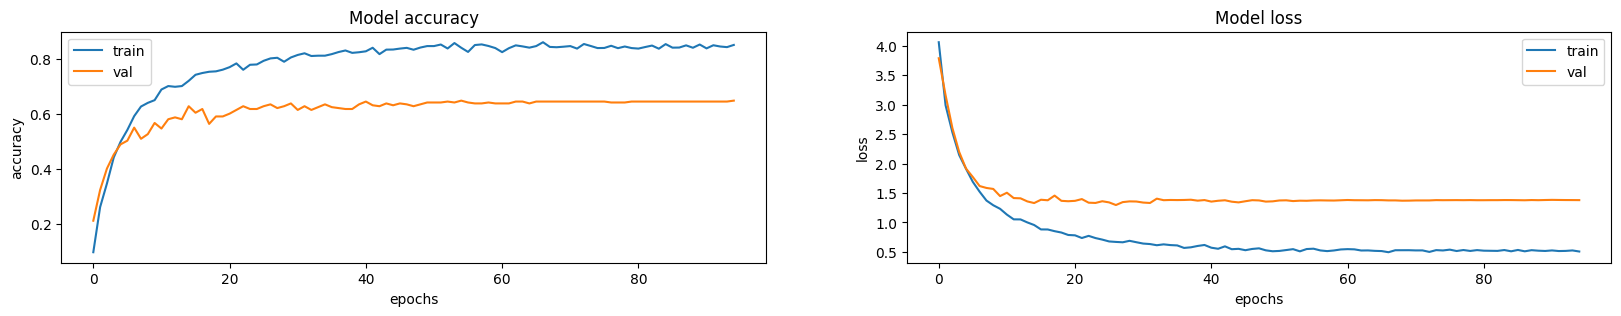

In [ ]:
historyA = fit_model(modelA)
plot(historyA)

test_loss, test_acc = modelA.evaluate(test_dataset)

print(f"Test Accuracy: {test_acc * 100:.2f}%\nTest Loss: {test_loss}")

### Risultati Task 2a

Con il backbone congelato, la convergenza è rapida data la ridotta dimensione dello spazio dei parametri addestrabili (solo la testa classificatoria). Il modello raggiunge una **validation accuracy di 64.86%** e una **test accuracy di 66.28%**, in linea con il **Model 4** del Task 1 (66.16%) ma con un gap train/val sensibilmente ridotto (training accuracy circa del 84% vs validation circa del 65%, contro il 95%/61% circa del **Model 4**). Ciò conferma che le feature estratte dalla ResNet-18 pre-addestrata su ImageNet-1K sono altamente trasferibili al dominio grocery anche senza alcun adattamento del backbone, garantendo una maggiore capacità di generalizzazione a parità di test accuracy.

## Modello Task 2b
Nel modello del Task 2b sblocchiamo l'intero backbone (`backbone.trainable = True`), mantenendo invariati tutti gli altri iperparametri rispetto al Task 2a. Un'alternativa che avevamo considerato era quella di congelare solo parzialmente il backbone, quindi applicare un partial unfreezing: congelare i primi layer (feature generiche come bordi e texture, utili per qualsiasi dominio) e sbloccare solo gli ultimi. Alla fine, si è scelto il fine-tuning completo perchè la distanza tra il dominio ImageNet e il dominio grocery è sufficientemente grande da richiedere un adattamento anche degli strati intermedi.

In [ ]:
def model_resnet18_task2b():
    backbone = models.ResNetBackbone.from_preset("resnet_18_imagenet")

    # Sblocca tutto il backbone
    backbone.trainable = True

    # Versione alternativa (partial freezing)
    # poi ricongela i primi layer (feature generiche ImageNet)
    # for layer in backbone.layers[:-30]:
    #     layer.trainable = False

    inputs, x = build_resnet_input()
    x = backbone(x, training=True)   # BN si adattano alla distribuzione grocery

    x = GlobalAveragePooling2D()(x)

    wd = 1e-4
    x = Dense(units=128, use_bias=False, kernel_regularizer=l2(wd))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(DROPOUT_RATE)(x)

    outputs = Dense(units=NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs, name="resnet18_task2b")
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [ ]:
modelB = model_resnet18_task2b()
modelB.summary()

Model: "resnet18_task2b"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_net_backbone                │ (None, 7, 7, 512)      │    11,186,112 │
│ (ResNetBackbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 81)             │        10,449 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,262,609 (42.96 MB)

 Trainable params: 11,252,753 (42.93 MB)

 Non-trainable params: 9,856 (38.50 KB)

Epoch 1/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - accuracy: 0.0890 - loss: 4.1499 - val_accuracy: 0.1419 - val_loss: 3.9137 - learning_rate: 0.0010
Epoch 2/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - accuracy: 0.3117 - loss: 2.8297 - val_accuracy: 0.3480 - val_loss: 2.9686 - learning_rate: 0.0010
Epoch 3/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.5068 - loss: 2.0389 - val_accuracy: 0.4662 - val_loss: 2.3163 - learning_rate: 0.0010
Epoch 4/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.6383 - loss: 1.5183 - val_accuracy: 0.5000 - val_loss: 1.8702 - learning_rate: 0.0010
Epoch 5/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - accuracy: 0.7360 - loss: 1.1236 - val_accuracy: 0.5405 - val_loss: 1.7452 - learning_rate: 0.0010
Epoch 6/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.8117 - loss: 0.8422 - val_accuracy: 0.5980 - val_loss: 1.5369 - learning_rate: 0.0010
Epoch 7/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.8500 - l

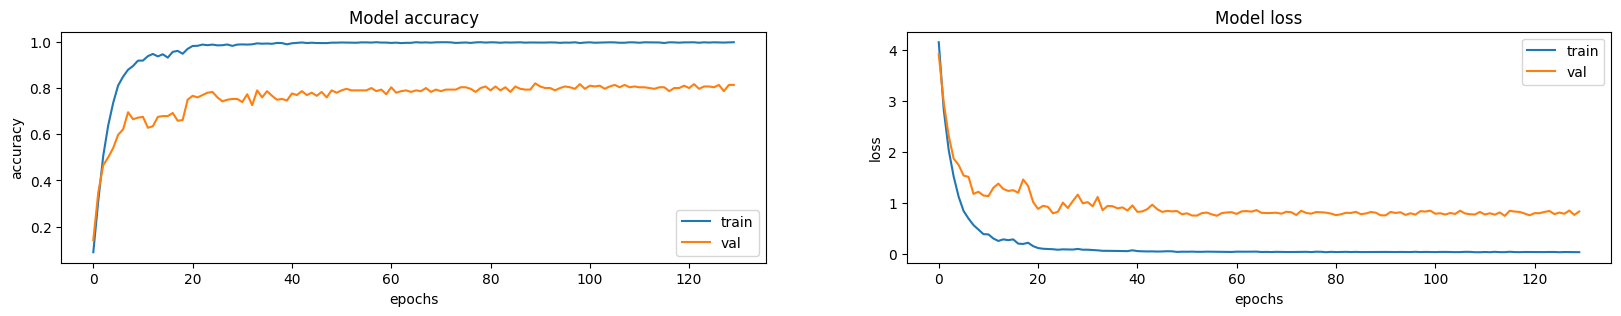

In [ ]:
historyB = fit_model(modelB)
plot(historyB)

test_loss, test_acc = modelB.evaluate(test_dataset)

print(f"Test Accuracy: {test_acc * 100:.2f}%\nTest Loss: {test_loss}")

### Risultati Task 2b

Il fine-tuning completo permette al backbone di specializzarsi sulla distribuzione del dominio grocery, producendo il miglioramento più significativo dell'intero progetto. Lo sblocco del backbone si è rivelato sufficiente, da solo, a raggiungere l'obiettivo dell'80–90% di validation accuracy prefissato, senza necessità di ulteriori interventi di ottimizzazione. In particolare, il modello raggiunge una **validation accuracy di 81.42%** e una **test accuracy di 84.83%** (test loss: 0.70). Il guadagno rispetto al Task 2a è di circa **18 punti percentuali** sulla test accuracy (da 66.28% a 84.83%).

## Riepilogo risultati Task 2
Gli esperimenti effettuati evidenziano la presenza di un gap tra i risultati dei due task confermando il guadagno dovuto all'adattamento del backbone. Infatti, le feature generali di ImageNet del **Task 2a** non catturano perfettamente le specificità del dominio grocery come texture di frutta e verdura, packaging dei prodotti confezionati, illuminazione da scaffale, ecc. Utilizzando il fine-tuning completo, come nel **Task 2b**, il modello si adatta a queste caratteristiche migliorando di molto i risultati finali ottenuti.

# Conclusioni finali

Il presente progetto ha affrontato il problema della classificazione di immagini di prodotti alimentari mediante reti neurali convoluzionali, articolandosi in due task distinti.

Nel **Task 1**, attraverso uno sviluppo incrementale di cinque architetture, è stato possibile passare da una test accuracy del 26.80% del Model 1 al **70.10%** del Model 5. La progressione ha evidenziato come batch normalization, data augmentation e regolarizzazione L2 siano componenti essenziali per il training su dataset di dimensioni ridotte, e come la supervisione gerarchica possa compensare efficacemente la scarsità di campioni.

Nel **Task 2**, il fine-tuning della ResNet-18 pre-addestrata su ImageNet ha permesso di superare nettamente i risultati del Task 1: il modello Task 2a (backbone congelato con stessi iperparametri del Task 1) ha raggiunto già una test accuracy del **66.28%** con una generalizzazione superiore, mentre il Task 2b (fine-tuning completo) ha portato la test accuracy a **84.83%**, attestandosi all'interno dell'intervallo target dell'80–90%.

Il confronto tra i due task evidenzia con chiarezza il vantaggio del transfer learning: le rappresentazioni apprese su una raccolta di dati vasta ed eterogenea come ImageNet-1K costituiscono un punto di partenza di qualità superiore rispetto a qualsiasi architettura addestrata da zero sul Grocery Store Dataset, con un guadagno finale di circa 15 punti percentuali sulla test accuracy.